In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1- Concatenar dos DataFrames  Descripción: Leer los archivos argentina_cars1.csv argentina_cars2.csv convertirlos en DataFrames y concatenarlos por filas.

In [2]:
df1 = pd.read_csv("argentina_cars1.csv")
df2 = pd.read_csv("argentina_cars2.csv")

df_total = pd.concat([df1, df2], axis=0)

print(df_total.head())
print("Cantidad total de registros:", len(df_total))

      money    brand          model  year        color fuel_type  door  \
0  10350000   Toyota  Corolla Cross  2022     Plateado     Nafta   5.0   
1  10850000     Jeep        Compass  2022       Blanco     Nafta   5.0   
2     35500     Jeep        Compass  2022  Gris oscuro     Nafta   5.0   
3     19000  Citroën      C4 Cactus  2022  Gris oscuro     Nafta   5.0   
4   5800000   Toyota        Corolla  2019         Gris     Nafta   4.0   

         gear motor body_type  kilometres currency  
0  Automática   NaN       SUV         500    pesos  
1  Automática   2.4       SUV         500    pesos  
2  Automática   2.4       SUV         500  dólares  
3  Automática   NaN       SUV         550  dólares  
4      Manual   1.8     Sedán        9000    pesos  
Cantidad total de registros: 510


# 2- Filtrar datos usando condicionales Descripción: Filtrar el nuevo DataFrame para obtener solo las filas donde una el valor del vehículo sea mayor a 3000000 y menor a 5000000, sea marca Volkswagen, sea modelo mayor a 2017 y sea de color blanco. Guardar este nuevo dataframe en un nuevo archivo .csv

In [2]:

df1 = pd.read_csv("argentina_cars1.csv")
df2 = pd.read_csv("argentina_cars2.csv")
df_total = pd.concat([df1, df2], axis=0)

df_filtrado = df_total[(df_total["money"] > 3000000) & (df_total["money"] < 5000000) & 
    (df_total["brand"] == "Volkswagen") & (df_total["year"] > 2017) & (df_total["color"] == "Blanco")]


df_filtrado.to_csv("volkswagen_filtrado.csv")

print(df_filtrado)


      money       brand    model  year   color fuel_type  door    gear motor  \
3   4589900  Volkswagen  Saveiro  2020  Blanco     Nafta   2.0  Manual   1.6   
48  4589900  Volkswagen  Saveiro  2020  Blanco     Nafta   2.0  Manual   1.6   

   body_type  kilometres currency  
3    Pick-Up       35000    pesos  
48   Pick-Up       37000    pesos  


# 3- Usar loc para seleccionar datos  Descripción: Seleccionar las columnas “brand”, “model” y “kilometres”. Luego armar un nuevo dataframe con todos los autos que tengan más de 10000 kilómetros.

In [8]:
df1 = pd.read_csv("argentina_cars1.csv")
df2 = pd.read_csv("argentina_cars2.csv")
df_total = pd.concat([df1, df2], axis=0)

df_seleccion = df_total.loc[:, ["brand", "model", "kilometres"]]
df_filtrado = df_seleccion[df_seleccion["kilometres"] > 10000]

print(df_filtrado.head())
print("Cantidad de autos con más de 10.000 km:", len(df_filtrado))

           brand    model  kilometres
5           Jeep  Compass       10500
6            Kia  Sorento      156000
7  Mercedes-Benz  Clase C      174000
8            BMW      220       66000
9     Volkswagen  T-Cross       35000
Cantidad de autos con más de 10.000 km: 475


# 4- Graficar un histograma con Matplotlib Descripción: Leer el archivo mundial.csv, armar un dataframe con selecciones y cantidad de mundiales ganados. Luego graficar un histograma. 

        Winners  count
0        Brazil      5
1         Italy      4
2  West Germany      3
3     Argentina      3
4       Uruguay      2
5        France      2
6       England      1
7         Spain      1
8       Germany      1


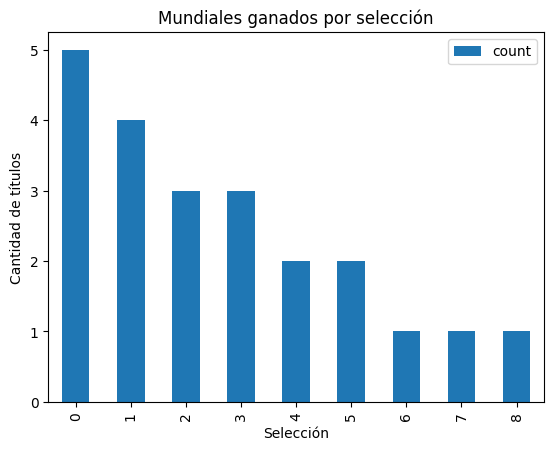

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mundial.csv")

df_mundiales = df["Winners"].value_counts().reset_index()
print(df_mundiales)

df_mundiales.plot(kind="bar")
plt.title("Mundiales ganados por selección")
plt.xlabel("Selección")
plt.ylabel("Cantidad de títulos")
plt.show()


# 5- Combinar gráficos con Matplotlib y Seaborn Descripción: Leer un archivo .csv producto de la unión de argentina_cars1.csv argentina_cars2.csv y combinar un gráfico de barras con un gráfico de líneas utilizando matplotlib o seaborn.

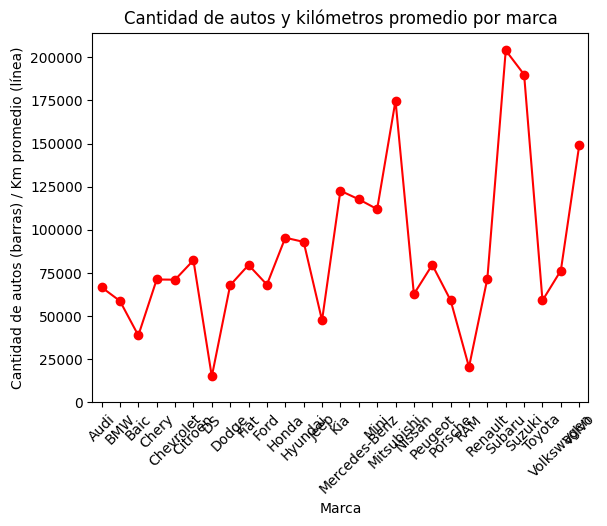

In [2]:
df1 = pd.read_csv("argentina_cars1.csv")
df2 = pd.read_csv("argentina_cars2.csv")
df_total = pd.concat([df1, df2], axis=0)

df_grouped = df_total.groupby("brand").agg(
    cantidad=("brand", "count"),
    km_promedio=("kilometres", "mean")
)

# 3. Gráfico combinado simple
ax = df_grouped["cantidad"].plot(kind="bar", color="skyblue")
df_grouped["km_promedio"].plot(kind="line", marker="o", color="red", ax=ax)

plt.title("Cantidad de autos y kilómetros promedio por marca")
plt.xlabel("Marca")
plt.ylabel("Cantidad de autos (barras) / Km promedio (línea)")
plt.xticks(rotation=45)
plt.show()

# 6- Realizar subplots con Matplotlib  Descripción: realizar 4 gráficos, que crea más conveniente,  de la combinación de los archivos argentina_cars1.csv y argentina_cars2.csv. 

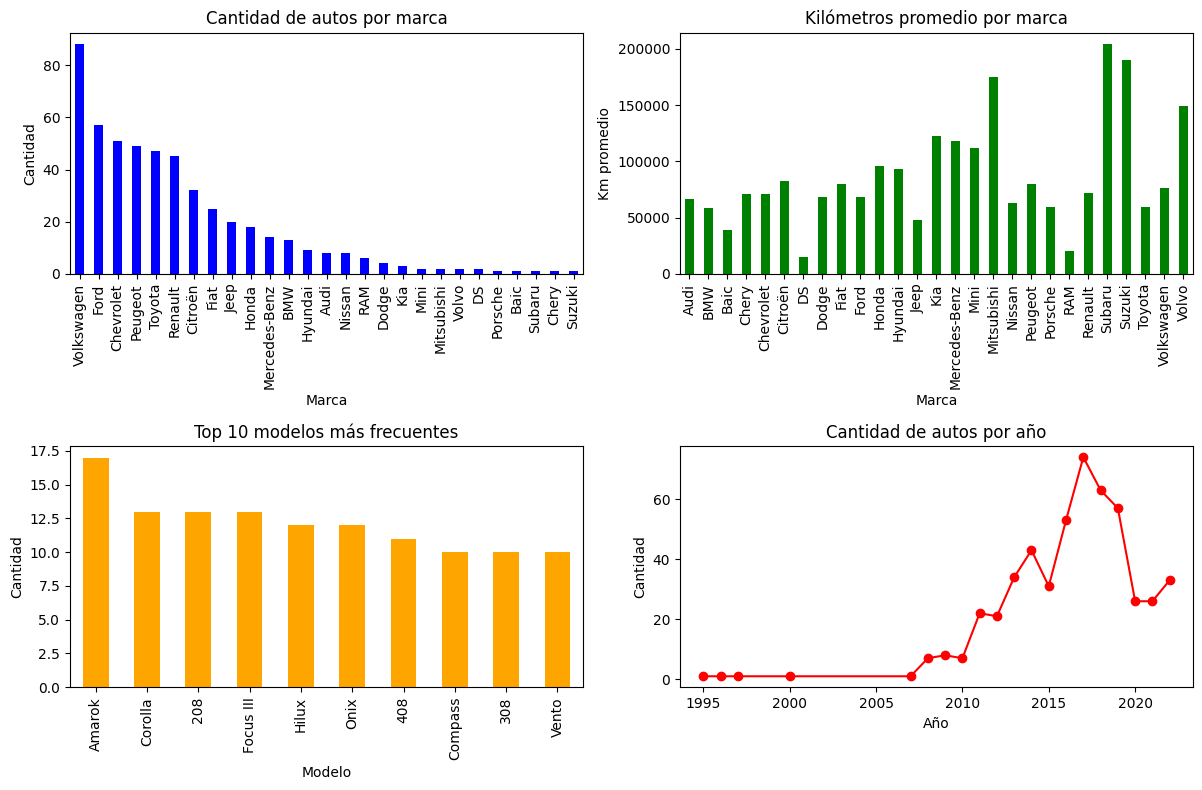

In [2]:
df1 = pd.read_csv("argentina_cars1.csv")
df2 = pd.read_csv("argentina_cars2.csv")
df_total = pd.concat([df1, df2], axis=0)


autos_por_marca = df_total["brand"].value_counts()
km_promedio = df_total.groupby("brand")["kilometres"].mean()
autos_por_modelo = df_total["model"].value_counts().head(10)
autos_por_año = df_total["year"].value_counts().sort_index()


fig, axes = plt.subplots(2, 2, figsize=(12,8))


autos_por_marca.plot(kind="bar", ax=axes[0,0], color="blue")
axes[0,0].set_title("Cantidad de autos por marca")
axes[0,0].set_xlabel("Marca")
axes[0,0].set_ylabel("Cantidad")


km_promedio.plot(kind="bar", ax=axes[0,1], color="green")
axes[0,1].set_title("Kilómetros promedio por marca")
axes[0,1].set_xlabel("Marca")
axes[0,1].set_ylabel("Km promedio")


autos_por_modelo.plot(kind="bar", ax=axes[1,0], color="orange")
axes[1,0].set_title("Top 10 modelos más frecuentes")
axes[1,0].set_xlabel("Modelo")
axes[1,0].set_ylabel("Cantidad")


autos_por_año.plot(kind="line", ax=axes[1,1], marker="o", color="red")
axes[1,1].set_title("Cantidad de autos por año")
axes[1,1].set_xlabel("Año")
axes[1,1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()